In [11]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [12]:
IMG_SIZE = 224
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 20
PATIENCE = 5

DATASET_PATH = "/kaggle/input/datasets/sumaiyaakter4789/py-crackdb-1/Classification"

In [13]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)

targets = dataset.targets

train_idx, val_idx = train_test_split(
    range(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [14]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()

        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, h, w = x.size()

        y = x.view(b, c, -1).mean(dim=2)
        y = torch.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        y = y.view(b, c, 1, 1)

        return x * y

In [15]:
class AttentionCNN(nn.Module):
    def __init__(self):
        super(AttentionCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            SEBlock(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            SEBlock(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            SEBlock(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            SEBlock(256),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = AttentionCNN().to(device)



In [16]:
def train_model(model):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_loss = float("inf")
    patience_counter = 0

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    start_time = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            best_model = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model)

    train_time = time.time() - start_time

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs
    }

    return model, train_time, history


In [17]:
model, train_time, history = train_model(model)

Epoch 1: Train Loss=0.6427, Val Loss=0.7179
Epoch 2: Train Loss=0.4686, Val Loss=0.7227
Epoch 3: Train Loss=0.3171, Val Loss=0.4311
Epoch 4: Train Loss=0.2363, Val Loss=0.5783
Epoch 5: Train Loss=0.2373, Val Loss=0.4332
Epoch 6: Train Loss=0.1827, Val Loss=0.3424
Epoch 7: Train Loss=0.1484, Val Loss=0.1574
Epoch 8: Train Loss=0.1329, Val Loss=0.1675
Epoch 9: Train Loss=0.1872, Val Loss=0.1578
Epoch 10: Train Loss=0.1704, Val Loss=0.8945
Epoch 11: Train Loss=0.1422, Val Loss=0.1445
Epoch 12: Train Loss=0.1107, Val Loss=0.1440
Epoch 13: Train Loss=0.0661, Val Loss=0.2065
Epoch 14: Train Loss=0.0872, Val Loss=0.3000
Epoch 15: Train Loss=0.1037, Val Loss=0.1703
Epoch 16: Train Loss=0.1042, Val Loss=0.0860
Epoch 17: Train Loss=0.0878, Val Loss=0.2272
Epoch 18: Train Loss=0.1004, Val Loss=0.1707
Epoch 19: Train Loss=0.0810, Val Loss=0.2038
Epoch 20: Train Loss=0.0591, Val Loss=0.1842


In [18]:
def evaluate_model(model):
    model.eval()

    all_labels, all_preds, all_probs = [], [], []

    start_time = time.time()

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.flatten())
            all_probs.extend(probs.flatten())

    test_time = time.time() - start_time

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "auc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "test_time": test_time
    }

metrics = evaluate_model(model)

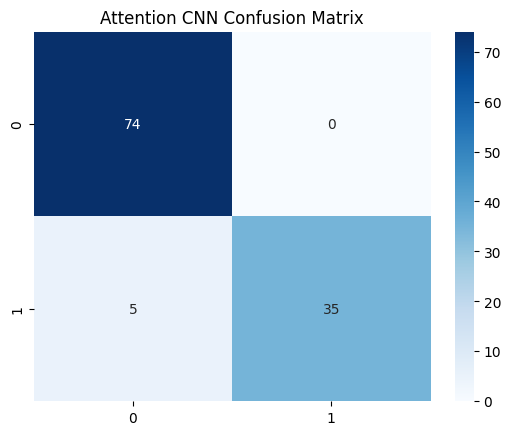

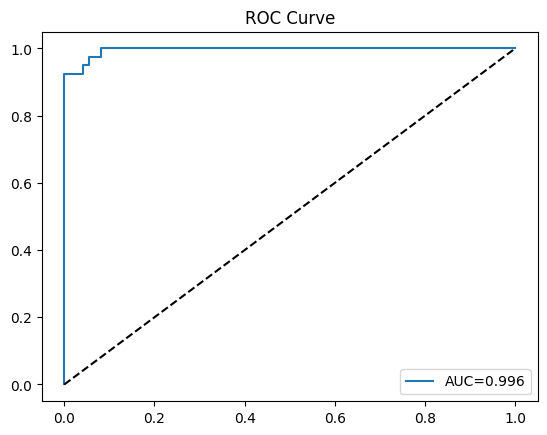

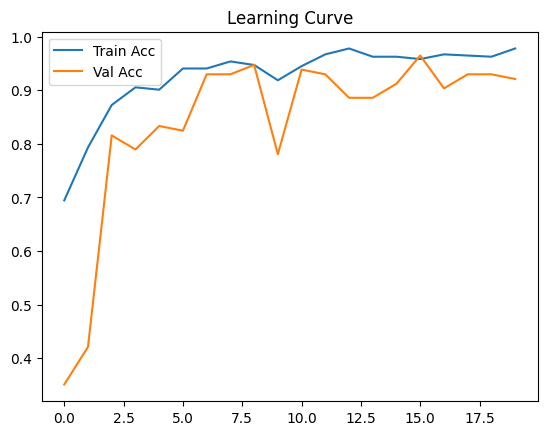

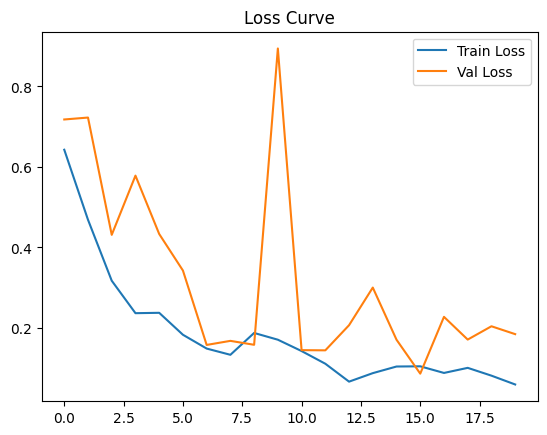

In [19]:
# Confusion Matrix
sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues")
plt.title("Attention CNN Confusion Matrix")
plt.show()

# ROC
plt.plot(metrics["fpr"], metrics["tpr"], label=f"AUC={metrics['auc']:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# Accuracy Curve
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.legend()
plt.title("Learning Curve")
plt.show()

# Loss Curve
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()



In [20]:
results = pd.DataFrame({
    "Model": ["Attention CNN"],
    "Accuracy": [metrics["accuracy"]],
    "Precision": [metrics["precision"]],
    "Recall": [metrics["recall"]],
    "F1-Score": [metrics["f1"]],
    "AUC": [metrics["auc"]],
    "Training Time (s)": [train_time],
    "Testing Time (s)": [metrics["test_time"]]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,AUC,Training Time (s),Testing Time (s)
0,Attention CNN,0.95614,1.0,0.875,0.933333,0.995608,1416.391319,6.162026
